# 2. Analysis

In [135]:
# This will delete all variables from the current session
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from typing import Literal
from datetime import datetime, timedelta
import geopandas as gpd

In [136]:
data_folder = "../../data/"
ara_data_folder = "../../data/newsapi/downloads/ara/"
eng_data_folder = "../../data/newsapi/downloads/eng/"

shapefiles_path = "../../data/shapefiles/"
plot_path = "../../plots/"

In [137]:
keyword_df = pd.read_csv(data_folder + "keywords_dataframe.csv")

In [138]:
keyword_codes_df = keyword_df.loc[keyword_df["keyword_eng"].isna(), ["column_name", "group_name"]].copy()
keyword_codes = keyword_codes_df.set_index("column_name")["group_name"].to_dict()

In [139]:
wb_shp_path = shapefiles_path + "WB_clean/WB_clean.shp"
wb_shp = gpd.read_file(wb_shp_path)

In [140]:
country_codes_df = wb_shp.loc[wb_shp["adml"] == 0, ["ID", "NAME"]].copy()
country_codes = country_codes_df.set_index("ID")["NAME"].to_dict()

In [141]:
def get_column_names(df, code, admin_level=-1):
    if admin_level == -1:
        return_list = [col for col in df.columns if col.startswith(code)]
    elif admin_level == 0:
        return_list = [col for col in df.columns if col.startswith(code) and len(col.split("_")) == 1]
    elif admin_level == 1:
        return_list = [col for col in df.columns if col.startswith(code) and len(col.split("_")) == 2]
    elif admin_level == 2:
        return_list = [col for col in df.columns if col.startswith(code) and len(col.split("_")) == 3]
                
    return return_list

In [142]:
admin_level_code = {"pr": "Province", "di": "District"}
languages = {"ara": "Arabic", "eng": "English"}

In [143]:
# English
eng = pd.read_csv(eng_data_folder + "Mashreq_2024-06-23_2024-07-24_daily_article_eng_clean_new.csv")

In [144]:
# Arabic
ara = pd.read_csv(ara_data_folder + "Mashreq_2024-06-23_2024-07-24_daily_article_ara_clean.csv")

## 2.1 Article length

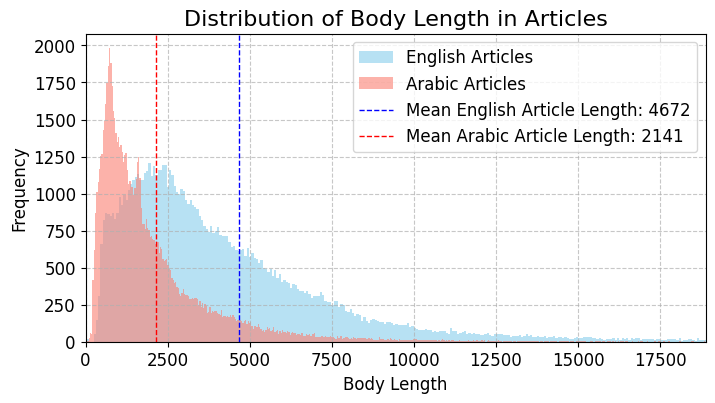

In [145]:
# Example data generation for demonstration
# Assuming `eng` and `ara` are DataFrames with a column `body_len`
eng_q98 = eng["body_len"].quantile(0.98)
ara_q98 = ara["body_len"].quantile(0.98)

plt.figure(figsize=(8, 4))
plt.hist(eng["body_len"], bins=1000, alpha=0.6, label="English Articles", color='skyblue')
plt.hist(ara["body_len"], bins=1000, alpha=0.6, label="Arabic Articles", color='salmon')

plt.axvline(eng["body_len"].mean(), color='blue', linestyle='dashed', linewidth=1, label=f"Mean English Article Length: {eng['body_len'].mean():.0f}")
plt.axvline(ara["body_len"].mean(), color='red', linestyle='dashed', linewidth=1, label=f"Mean Arabic Article Length: {ara['body_len'].mean():.0f}")

plt.xlim(0, max(ara_q98, eng_q98))
plt.tick_params(axis='both', which='major', labelsize=12)
plt.xlabel('Body Length', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Body Length in Articles', fontsize=16)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [146]:
# Example data generation for demonstration
# Assuming `eng` and `ara` are DataFrames with a column `body_len`
eng_q98 = eng["body_len_str"].quantile(0.98)
ara_q98 = ara["body_len_str"].quantile(0.98)

plt.figure(figsize=(8, 4))
plt.hist(eng["body_len_str"], bins=1000, alpha=0.6, label="English Articles", color='skyblue')
plt.hist(ara["body_len_str"], bins=1000, alpha=0.6, label="Arabic Articles", color='salmon')

plt.axvline(eng["body_len_str"].mean(), color='blue', linestyle='dashed', linewidth=1, label=f"Mean English Article Length: {eng['body_len_str'].mean():.0f}")
plt.axvline(ara["body_len_str"].mean(), color='red', linestyle='dashed', linewidth=1, label=f"Mean Arabic Article Length: {ara['body_len_str'].mean():.0f}")

plt.xlim(0, max(ara_q98, eng_q98))
plt.tick_params(axis='both', which='major', labelsize=12)
plt.xlabel('Body Length', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Body Length in Articles', fontsize=16)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

KeyError: 'body_len_str'

In [174]:
eng = eng.sort_values(by="body_len_str").reset_index(drop=True)

In [200]:
eng.loc[eng["body"].str.endswith("...")]

,uri,lang,isDuplicate,date,time,dateTime,dateTimePub,dataType,sim,url,...,sy_di_lattakia,sy_di_idleb,sy_di_hasakeh,sy_di_deir-ez-zor,sy_di_tartous,sy_di_raqqa,sy_di_dar'a,sy_di_sweida,sy_di_quneitra,body_len_str
43,8232477359,eng,False,2024-07-18,21:35:53,2024-07-18T21:35:53Z,2024-07-18T21:35:08Z,news,0.000000,https://worldview.stratfor.com/article/conflic...,...,0,0,0,0,0,0,0,0,0,39
53,8195253769,eng,False,2024-06-25,19:29:58,2024-06-25T19:29:58Z,2024-06-25T19:28:39Z,news,0.592157,https://worldview.stratfor.com/article/frances...,...,0,0,0,0,0,0,0,0,0,43
54,8216731992,eng,False,2024-07-09,10:22:59,2024-07-09T10:22:59Z,2024-07-09T10:22:53Z,news,0.717647,http://www.sta.si/http.php?id=3320327,...,0,0,0,0,0,0,0,0,0,43
62,8223522530,eng,False,2024-07-13,09:27:19,2024-07-13T09:27:19Z,2024-07-13T09:26:46Z,news,0.000000,https://worldview.stratfor.com/article/essenti...,...,0,0,0,0,0,0,0,0,0,45
64,8207743896,eng,False,2024-07-03,12:12:08,2024-07-03T12:12:08Z,2024-07-03T12:12:03Z,news,0.000000,http://www.sta.si/http.php?id=3318481,...,0,0,0,0,0,0,0,0,0,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75143,8211252410,eng,False,2024-07-05,13:13:39,2024-07-05T13:13:39Z,2024-07-05T13:13:16Z,news,0.486275,https://www.indy100.com/politics/prime-minster...,...,0,0,0,0,0,0,0,0,0,2305
75336,8194445815,eng,False,2024-06-25,10:30:18,2024-06-25T10:30:18Z,2024-06-25T10:29:13Z,news,0.631373,https://www.phillyvoice.com/10-reasons-giants-...,...,0,0,0,0,0,0,0,0,0,2387
76465,2024-07-419427206,eng,False,2024-07-12,06:36:55,2024-07-12T06:36:55Z,2024-07-12T06:00:00Z,news,0.596078,https://www.politico.eu/newsletter/london-play...,...,0,0,0,0,0,0,0,0,0,3174
77344,2024-07-415836131,eng,False,2024-07-09,06:50:45,2024-07-09T06:50:45Z,2024-07-09T06:30:30Z,news,0.576471,https://qnewshub.com/reviews/best-of-clickbank...,...,0,0,0,0,0,0,0,0,0,4891


In [191]:
df = eng[["body_len_str","url","source","body"]]

In [192]:
df = df.iloc[:1000]

In [193]:
df.to_csv(eng_data_folder + "shortest_200.csv", index=False)

## 2.2 Publishing date vs scraping date

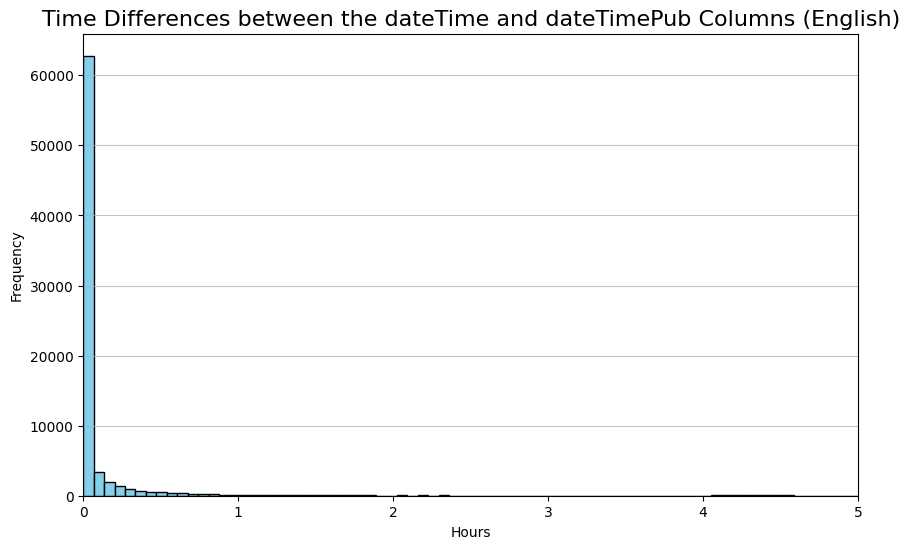

In [70]:
eng["diff"] = pd.to_datetime(eng["dateTime"]) - pd.to_datetime(eng["dateTimePub"])

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(eng["diff"].dt.total_seconds() / 3600, bins=1000, edgecolor='black', color='skyblue')
plt.title('Time Differences between the dateTime and dateTimePub Columns (English)', fontsize=16)
plt.xlabel('Hours')
plt.xlim(0, 5)
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

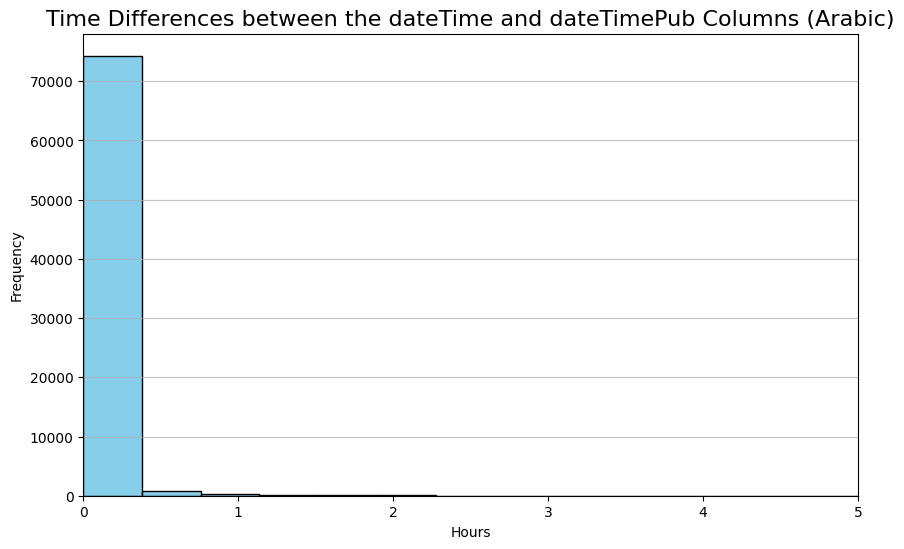

In [71]:
ara["diff"] = pd.to_datetime(ara["dateTime"]) - pd.to_datetime(ara["dateTimePub"])

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(ara["diff"].dt.total_seconds() / 3600, bins=1000, edgecolor='black', color='skyblue')
plt.title('Time Differences between the dateTime and dateTimePub Columns (Arabic)', fontsize=16)
plt.xlabel('Hours')
plt.ylabel('Frequency')
plt.xlim(0, 5)
plt.grid(axis='y', alpha=0.75)

## 2.3 Summary of Articles mentioning countries, provinces and districts with and without keywords

Note that in this summary, articles that mention multiple districts or that mention multiple keywords or keywords multiple times appear in each column only once. 

In [214]:
def create_count_summary_df(language_df: pd.DataFrame, keyword_columns: list, country_codes: dict):
    """
    Creates a summary DataFrame that counts the number of articles and keywords for each country and its provinces/districts.
    Different from the 

    Args:
        language_df (pd.DataFrame): The DataFrame containing the language-specific articles.
        keyword_columns (list): A list of column names representing the keyword columns in the DataFrame.
        country_codes (dict): A dictionary mapping country codes to their corresponding names.

    Returns:
        pd.DataFrame: A DataFrame summarizing the article and keyword counts for each country and its provinces/districts.
    """
    articles = language_df.shape[0]
    articles_keywords = language_df.loc[language_df[keyword_columns].sum(axis=1) > 0,].shape[0]

    country_code_list = []
    articles_country_list = []
    articles_country_provinces_list = []
    articles_provinces_list = []
    articles_country_districts_list = []
    articles_districts_list = []
    articles_country_keywords_list = []
    articles_country_provinces_keywords_list = []
    articles_provinces_keywords_list = []
    articles_country_districts_keywords_list = []
    articles_districts_keywords_list = []
    
    #print(f'Out of {articles} {languages[language_df["lang"].unique()[0]]} articles from {language_df["date"].min().date()} to {language_df["date"].max().date()}, {articles_keywords} ({np.round(articles_keywords/articles*100,2)} %) mention keywords:')
    for country_code in country_codes.keys():
        articles_country = language_df.loc[language_df[get_column_names(language_df, country_code + "_" + country_codes[country_code].lower())[0]] > 0, ].shape[0]
        articles_country_provinces = language_df.loc[(language_df[get_column_names(language_df, country_code + "_" + country_codes[country_code].lower())[0]] > 0) & (language_df[get_column_names(language_df, country_code + "_pr")].sum(axis=1) > 0),].shape[0]
        articles_provinces = language_df.loc[(language_df[get_column_names(language_df, country_code + "_pr")].sum(axis=1) > 0),].shape[0]
        articles_country_districts = language_df.loc[(language_df[get_column_names(language_df, country_code + "_" + country_codes[country_code].lower())[0]] > 0) & (language_df[get_column_names(language_df, country_code + "_di")].sum(axis=1) > 0),].shape[0]
        articles_districts = language_df.loc[(language_df[get_column_names(language_df, country_code + "_di")].sum(axis=1) > 0),].shape[0]
        
        articles_country_keywords = language_df.loc[(language_df[get_column_names(language_df, country_code + "_" + country_codes[country_code].lower())[0]] > 0) & (language_df[keyword_columns].sum(axis=1) > 0), ].shape[0]
        articles_country_provinces_keywords = language_df.loc[(language_df[get_column_names(language_df, country_code + "_" + country_codes[country_code].lower())[0]] > 0) & (language_df[get_column_names(language_df, country_code + "_pr")].sum(axis=1) > 0) & (language_df[keyword_columns].sum(axis=1) > 0),].shape[0]
        articles_provinces_keywords = language_df.loc[(language_df[get_column_names(language_df, country_code + "_pr")].sum(axis=1) > 0) & (language_df[keyword_columns].sum(axis=1) > 0),].shape[0]
        
        articles_country_districts_keywords = language_df.loc[(language_df[get_column_names(language_df, country_code + "_" + country_codes[country_code].lower())[0]] > 0) & (language_df[get_column_names(language_df, country_code + "_di")].sum(axis=1) > 0) & (language_df[keyword_columns].sum(axis=1) > 0),].shape[0]
        articles_districts_keywords = language_df.loc[(language_df[get_column_names(language_df, country_code + "_di")].sum(axis=1) > 0) & (language_df[keyword_columns].sum(axis=1) > 0),].shape[0]
        
        country_code_list.append(country_code)
        articles_country_list.append(articles_country)
        articles_country_provinces_list.append(articles_country_provinces)
        articles_provinces_list.append(articles_provinces)
        articles_country_districts_list.append(articles_country_districts)
        articles_districts_list.append(articles_districts)
        articles_country_keywords_list.append(articles_country_keywords)
        articles_country_provinces_keywords_list.append(articles_country_provinces_keywords)
        articles_provinces_keywords_list.append(articles_provinces_keywords)
        articles_country_districts_keywords_list.append(articles_country_districts_keywords)
        articles_districts_keywords_list.append(articles_districts_keywords)
                
        #print(f"\t- {country_codes[country_code]}: {articles_country_keywords} of {articles_country} ({np.round(articles_country_keywords / articles_country * 100,2)} %), provinces of {country_codes[country_code]}: {articles_provinces_keywords} of {articles_provinces} ({np.round(articles_provinces_keywords / articles_provinces * 100,2)} %), both: {articles_country_provinces_keywords} of {articles_country_provinces} ({np.round(articles_country_provinces_keywords / articles_country_provinces * 100,2)} %).")
        
    mention_count_df = pd.DataFrame({"country_code": country_code_list, "articles_country": articles_country_list, "articles_country_provinces": articles_country_provinces_list, "articles_provinces": articles_provinces_list, "articles_country_districts": articles_country_districts_list, "articles_districts": articles_districts_list, "articles_country_keywords": articles_country_keywords_list, "articles_country_provinces_keywords": articles_country_provinces_keywords_list, "articles_provinces_keywords": articles_provinces_keywords_list, "articles_country_districts_keywords": articles_country_districts_keywords_list, "articles_districts_keywords": articles_districts_keywords_list})
    return mention_count_df

In [215]:
# English
mention_count_df_eng = create_count_summary_df(eng, keyword_columns_eng, country_codes)

In [78]:
# Arabic
mention_count_df_ara = create_count_summary_df(ara, keyword_columns_ara, country_codes)

In [79]:
def plot_mention_count_summary(mention_count_df:pd.DataFrame, language: Literal["eng", "ara"], from_date: str, to_date: str, plot_path: str, save_plot: bool = False):

    # Calculate the first bar heights
    articles_country_no_keywords = mention_count_df["articles_country"] - mention_count_df["articles_country_keywords"]
    articles_provinces_no_keywords = mention_count_df["articles_provinces"] - mention_count_df["articles_provinces_keywords"]
    articles_country_provinces_no_keywords = mention_count_df["articles_country_provinces"] - mention_count_df["articles_country_provinces_keywords"]
    articles_districts_no_keywords = mention_count_df["articles_districts"] - mention_count_df["articles_districts_keywords"]
    articles_country_districts_no_keywords = mention_count_df["articles_country_districts"] - mention_count_df["articles_country_districts_keywords"]

    labels = ["Country", "Province", "Country & Province", "Districts", "Country & Districts"]
    labels = np.repeat(labels,5)

    # Define the positions for each group of bars
    n_groups = len(mention_count_df)
    bar_height = 0.15
    index = np.arange(n_groups)

    # Plot the bars
    plt.figure(figsize=(12, 8))

    # Type 1 - Articles per Country
    plt.barh(
        index, 
        articles_country_no_keywords, 
        bar_height, 
        color='salmon', 
        edgecolor="black",
        label='Not Including Keywords'
    )
    plt.barh(
        index, 
        mention_count_df["articles_country_keywords"], 
        bar_height, 
        left=articles_country_no_keywords, 
        color='green', 
        edgecolor="black",
        label='Including Keywords'
    )

    # Type 2 - Articles per Province
    plt.barh(
        index + bar_height, 
        articles_provinces_no_keywords, 
        bar_height, 
        color='salmon', 
        edgecolor="black",
        #label='Not Including Keywords'
    )
    plt.barh(
        index + bar_height, 
        mention_count_df["articles_provinces_keywords"], 
        bar_height, 
        left=articles_provinces_no_keywords, 
        color='green', 
        edgecolor="black",
        #label='Including Keywords'
    )

    # Type 3 - Articles per Country and Province
    plt.barh(
        index + 2 * bar_height, 
        articles_country_provinces_no_keywords, 
        bar_height, 
        color='salmon', 
        edgecolor="black",
        #label='Not Including Keywords'
    )
    plt.barh(
        index + 2 * bar_height, 
        mention_count_df["articles_country_provinces_keywords"], 
        bar_height, 
        left=articles_country_provinces_no_keywords, 
        color='green', 
        edgecolor="black",
        #label='Including Keywords'
    )

    # Type 4 - Articles per District
    plt.barh(
        index + 3 * bar_height, 
        articles_districts_no_keywords, 
        bar_height, 
        color='salmon', 
        edgecolor="black",
        #label='Not Including Keywords'
    )
    plt.barh(
        index + 3 * bar_height, 
        mention_count_df["articles_districts_keywords"], 
        bar_height, 
        left=articles_districts_no_keywords, 
        color='green', 
        edgecolor="black",
        #label='Including Keywords'
    )

    # Type 5 - Articles per Country and District
    plt.barh(
        index + 4 * bar_height, 
        articles_country_districts_no_keywords, 
        bar_height, 
        color='salmon', 
        edgecolor="black",
        #label='Not Including Keywords'
    )
    plt.barh(
        index + 4 * bar_height, 
        mention_count_df["articles_country_districts_keywords"], 
        bar_height, 
        left=articles_country_districts_no_keywords, 
        color='green', 
        edgecolor="black"
        #label='Including Keywords'
    )

    # Add labels and title
    plt.xlabel('Number of Articles')
    plt.title(f'Number of {languages[language]} Articles Mentioning Keywords by Country and Administrative Level from {from_date} to {to_date}', loc='center', pad=20, x=0.4)
    label_locations = list(index) + list(index + bar_height) + list(index + 2 * bar_height) + list(index + 3 * bar_height) + list(index + 4 * bar_height)
    plt.yticks(label_locations, labels)

    plt.text(-np.max(mention_count_df.max().values[1:])/3.2, index[4] + 2 * bar_height, "Syria", fontsize=18, color='black')
    plt.text(-np.max(mention_count_df.max().values[1:])/3.2, index[3] + 2 * bar_height, "Palestine", fontsize=18, color='black')
    plt.text(-np.max(mention_count_df.max().values[1:])/3.2, index[2] + 2 * bar_height, "Lebanon", fontsize=18, color='black')
    plt.text(-np.max(mention_count_df.max().values[1:])/3.2, index[1] + 2 * bar_height, "Jordan", fontsize=18, color='black')
    plt.text(-np.max(mention_count_df.max().values[1:])/3.2, index[0] + 2 * bar_height, "Iraq", fontsize=18, color='black')
    plt.legend()

    plt.tight_layout()
    if save_plot:
        plt.savefig(plot_path + "keyword-admin-level/" + f"summary_{from_date}_to_{to_date}_{language}.png")
        
    # Display the plot
    plt.show()

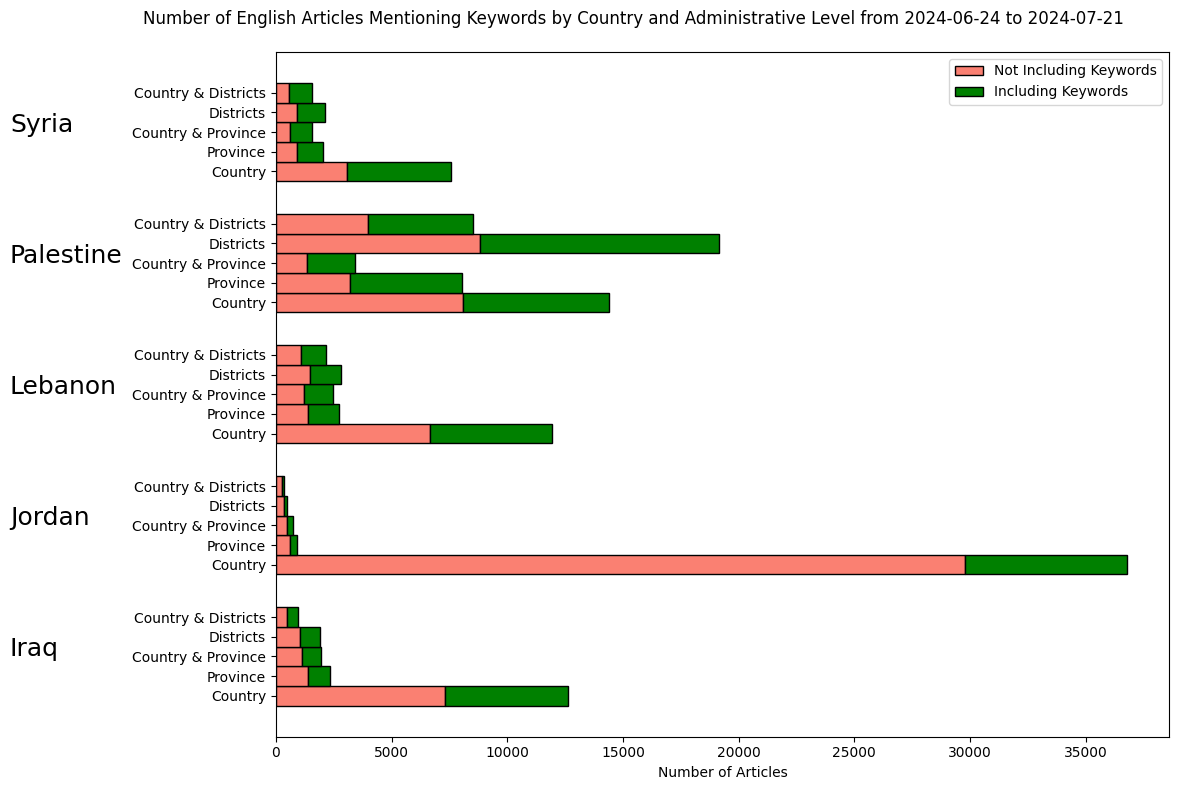

In [83]:
# English
plot_mention_count_summary(mention_count_df_eng, "eng", from_date, to_date, plot_path, save_plot = True)

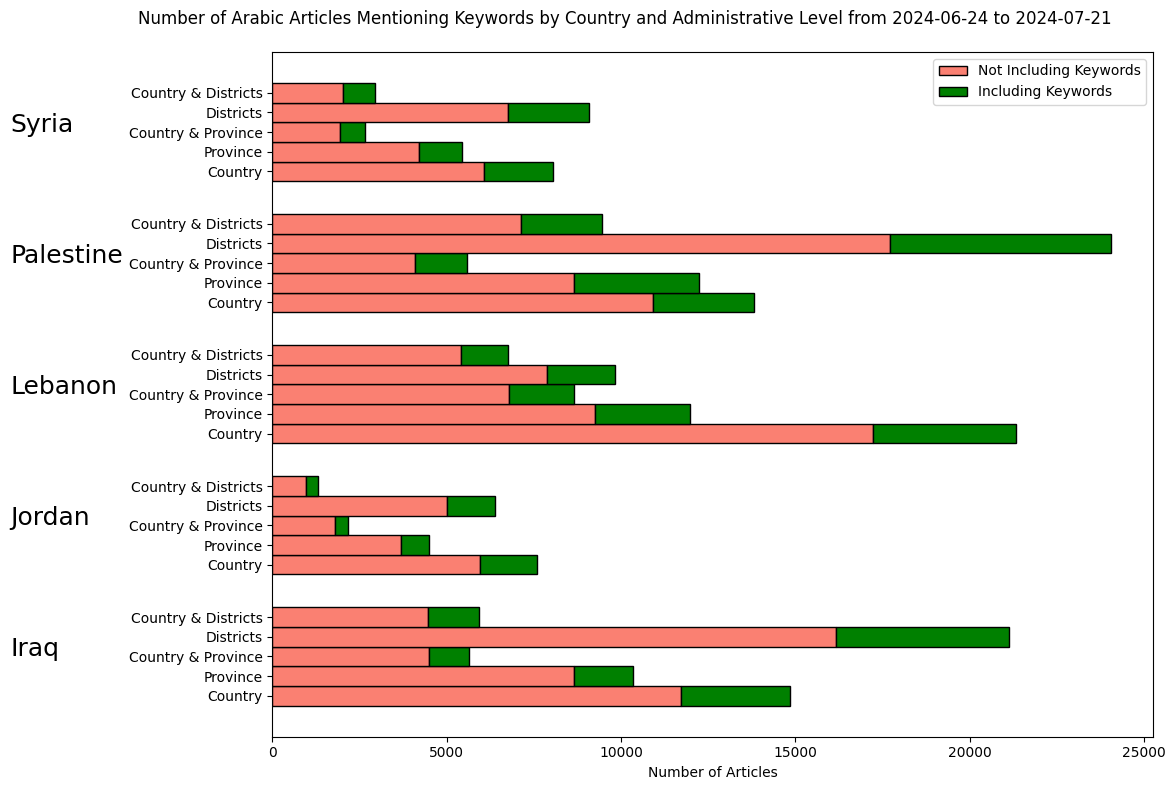

In [84]:
# Arabic
plot_mention_count_summary(mention_count_df_ara, "ara", from_date, to_date, plot_path, save_plot = True)

## 2.4 Summary of articles for locations as admin level 0, level 1 and level 2 per day

In [267]:
def create_summary_pivot_table(df_summary: pd.DataFrame) -> pd.DataFrame:
    df_summary = df_summary[['date', 'location_name'] + list(keyword_codes.keys())]
    
    # Melt the DataFrame to have a long format
    df_melted = pd.melt(df_summary, id_vars=['date', 'location_name'], var_name='metric', value_name='value')

    # Create a new column combining date and metric
    df_melted['date_metric'] = df_melted['date'].astype(str) + '_' + df_melted['metric']

    # Pivot the table
    df_pivot = df_melted.pivot_table(index='location_name', columns='date_metric', values='value').reset_index()

    # If you want to flatten the MultiIndex in columns
    df_pivot.columns = [str(col) for col in df_pivot.columns]

    return df_pivot

In [277]:
df_pivot_summary_iraq_country = create_summary_pivot_table(summary_iraq_country)
df_pivot_summary_iraq_provinces = create_summary_pivot_table(summary_iraq_provinces)
df_pivot_summary_iraq_districts = create_summary_pivot_table(summary_iraq_districts)

In [278]:
df_pivot_summary_iraq_country["admin_level"] = 0
df_pivot_summary_iraq_provinces["admin_level"] = 1
df_pivot_summary_iraq_districts["admin_level"] = 2

In [279]:
df_pivot_summary_iraq_districts = df_pivot_summary_iraq_districts.merge(shapefile_province_district_match, left_on="location_name", right_on="ADM2_EN_cl", how="left").drop("ADM2_EN_cl", axis=1)
df_pivot_summary_iraq_districts.rename(columns={"ADM1_EN_cl": "province"}, inplace=True)

In [280]:
df_pivot_summary_iraq_provinces["province"] = df_pivot_summary_iraq_provinces["location_name"]

In [281]:
df_pivot_summary_iraq = pd.concat([df_pivot_summary_iraq_country, df_pivot_summary_iraq_provinces, df_pivot_summary_iraq_districts], ignore_index=True)

In [285]:
df_pivot_summary_iraq["country"] = "Iraq"

In [286]:
df_pivot_summary_iraq.to_csv(eng_data_folder + "Mashreq_2024-06-23_2024-07-24_daily_article_eng_clean_summary_nocountry_iraq.csv", index=False)

### 2.4.2 Aggregating the summary table to weeks, months (not implemented yet) or years

In [88]:
def unique_strings(series):
    return ', '.join(series.dropna().astype(str).unique())

def aggregate_summary_by_dates(summary_df: pd.DataFrame, level_of_aggregation:Literal["W", "M", "Y"]) -> pd.DataFrame:
    summary_df_agg = summary_df.groupby(["admin_level", "include_country"]).resample(level_of_aggregation).agg({col: 'sum' if summary_df[col].dtype != 'object' else unique_strings for col in summary_df.columns})
    summary_df_agg = summary_df_agg.drop(columns=["admin_level", "include_country"]).reset_index()
    summary_df_agg.sort_values(by=["country", "admin_level"], ascending=False, inplace=True)
    return summary_df_agg

In [89]:
# English
summary_df_eng_W = aggregate_summary_by_dates(summary_df_eng, "W")  # Weekly aggregation
summary_df_eng_Y = aggregate_summary_by_dates(summary_df_eng, "YE") # Yearly aggregation

In [90]:
# Arabic
summary_df_ara_W = aggregate_summary_by_dates(summary_df_ara, "W")  # Weekly aggregation
summary_df_ara_Y = aggregate_summary_by_dates(summary_df_ara, "YE") # Yearly aggregation

### 2.4.3 Plot the aggregated article counts per location

In [145]:
def plot_keyword_province(summary_df: pd.DataFrame, language_df: pd.DataFrame, country: str, plot_path: str, admin_level: str = "district", save_plot: bool = False):
    from_date = language_df["date"].min().date()
    to_date = language_df["date"].max().date()
    language = languages[language_df["lang"].unique()[0]]

    
    if admin_level == "district":
        adminlevel_df = summary_df.loc[(summary_df["country"] == country) & (summary_df["admin_level"].str.startswith("Di_")),]
        admin_names = adminlevel_df["admin_level"].str.replace("Di_", "").apply(lambda x: " ".join([y.capitalize() for y in x.split("_")])).values
        
        article_count = summary_df.loc[(summary_df["country"] == country) & (summary_df["admin_level"].str.startswith("Di_")),"count_articles"].values
        
        article_with_keywords_count = summary_df.loc[(summary_df["country"] == country) & (summary_df["admin_level"].str.startswith("Di_")),"kw"].values
        
        total_locations = summary_df.loc[(summary_df["country"] == country) & (summary_df["admin_level"].str.startswith("Di_"))].shape[0]
        locations_with_data_no_keywords = summary_df.loc[(summary_df["country"] == country) & (summary_df["admin_level"].str.startswith("Di_")) & (summary_df["count_articles"] - summary_df["kw"] > 0)].shape[0]
        locations_with_keywords = summary_df.loc[(summary_df["country"] == country) & (summary_df["admin_level"].str.startswith("Di_")) & (summary_df["kw"] > 0)].shape[0]
    
        
    elif admin_level == "province":
        adminlevel_df = summary_df.loc[(summary_df["country"] == country) & (summary_df["admin_level"].str.startswith("Pr_")),]
        admin_names = adminlevel_df["admin_level"].str.replace("Pr_", "").apply(lambda x: " ".join([y.capitalize() for y in x.split("_")])).values
        
        article_count = summary_df.loc[(summary_df["country"] == country) & (summary_df["admin_level"].str.startswith("Pr_")),"count_articles"].values
        
        article_with_keywords_count = summary_df.loc[(summary_df["country"] == country) & (summary_df["admin_level"].str.startswith("Pr_")),"kw"].values
        
        total_locations = summary_df.loc[(summary_df["country"] == country) & (summary_df["admin_level"].str.startswith("Pr_"))].shape[0]
        locations_with_data_no_keywords = summary_df.loc[(summary_df["country"] == country) & (summary_df["admin_level"].str.startswith("Pr_")) & (summary_df["count_articles"] > 0) & (summary_df["count_articles"] - summary_df["kw"] > 0)].shape[0]
        locations_with_keywords = summary_df.loc[(summary_df["country"] == country) & (summary_df["admin_level"].str.startswith("Pr_")) & (summary_df["kw"] > 0)].shape[0]
    
    else:
        print("Admin level not specified correctly, needs to be either 'district' or 'province'")
        
    article_with_no_keywords_count = article_count - article_with_keywords_count

    plt.figure(figsize=(6, max(6,int(len(admin_names)/6))))
    # Create the plot
    plt.barh(admin_names, article_with_no_keywords_count, color='salmon', label=f'Articles without Keywords (in {locations_with_data_no_keywords} {admin_level.capitalize()}s)')
    plt.barh(admin_names, article_with_keywords_count, left=article_with_no_keywords_count, color='green', label=f'Articles with Keywords (in {locations_with_keywords} {admin_level.capitalize()}s)')
    plt.xlabel('Article Count')
    plt.ylabel(f'{admin_level.capitalize()}')
    plt.title(f'{country} - {language} Articles - {total_locations} {admin_level.capitalize()}s ({from_date} to {to_date})')
    plt.legend()

    plt.tight_layout()
    
    # Display the plot
    if save_plot:
        plt.savefig(plot_path + "keyword-admin-level/" + f"{country.lower()}_{admin_level}s_{from_date}_to_{to_date}_{language_df['lang'].unique()[0]}.png")
    plt.show()

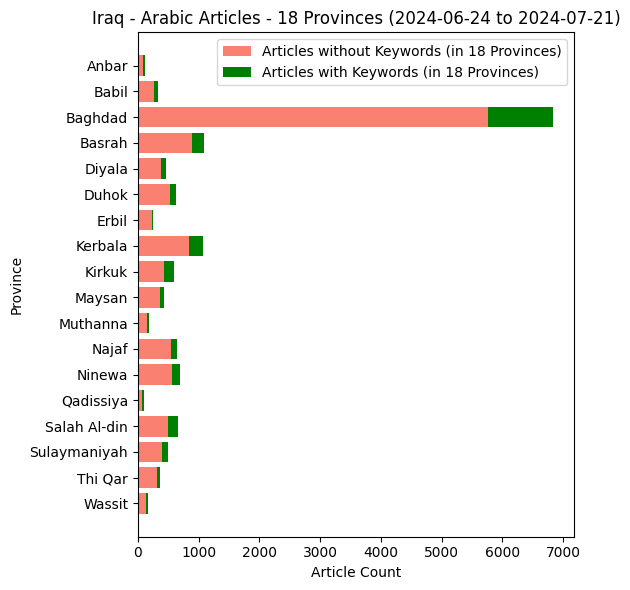

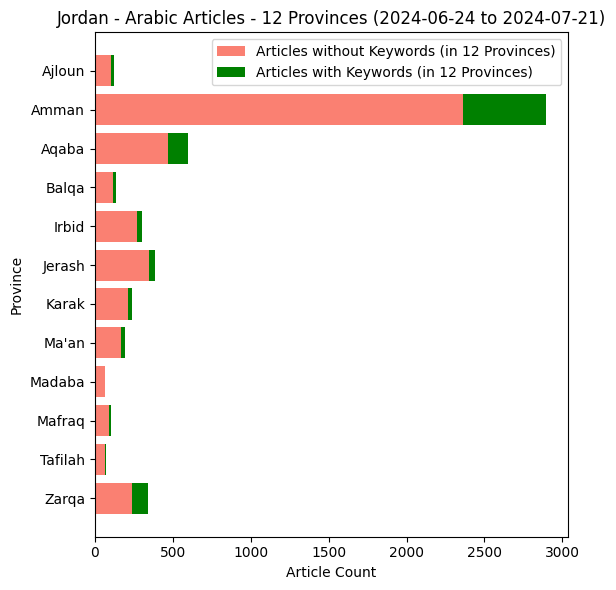

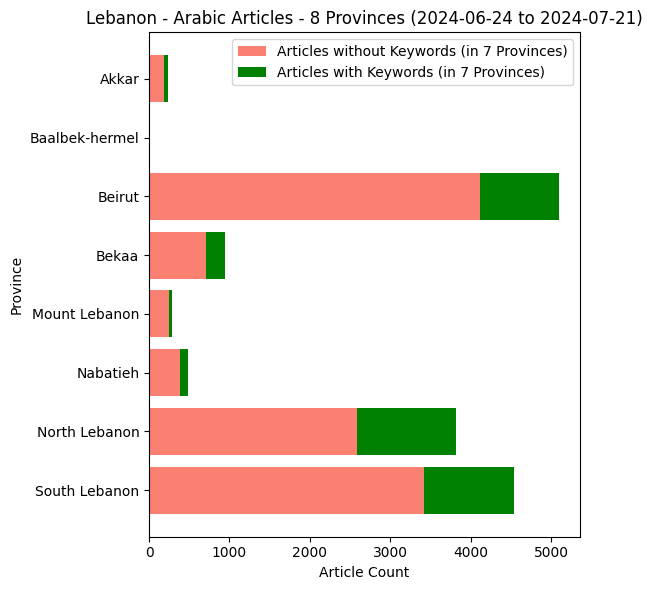

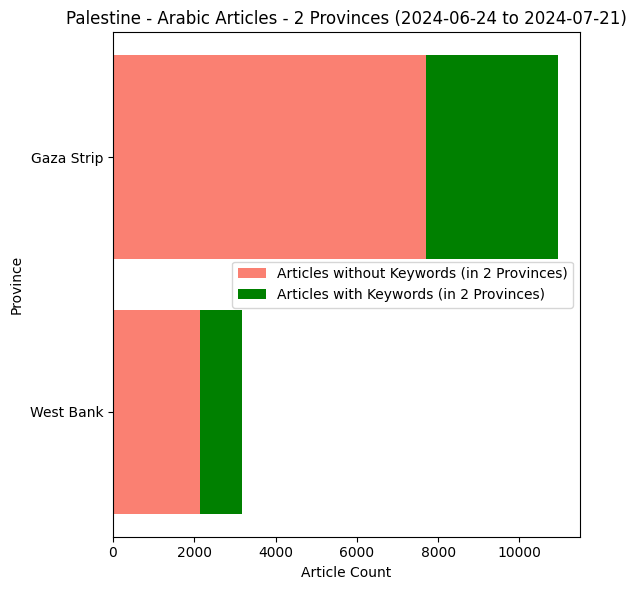

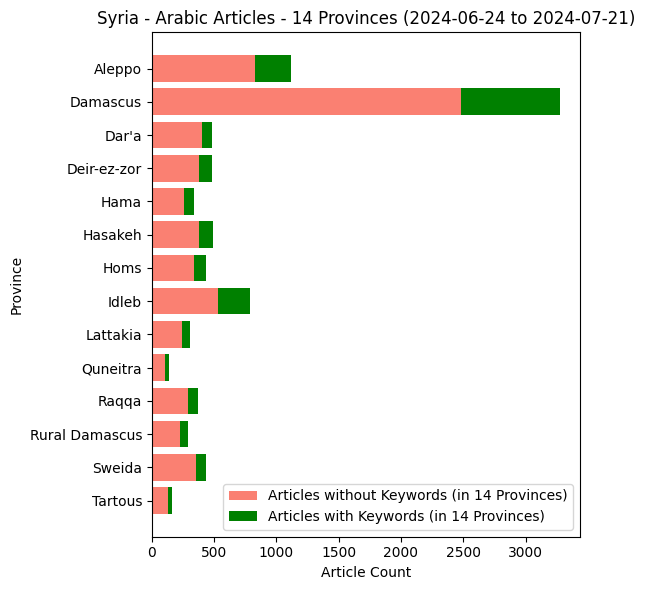

In [147]:
# Arabic
countries = ["Iraq", "Jordan", "Lebanon", "Palestine", "Syria"]
#admin_level = "district"
admin_level = "province"

for country in countries:
    summary_df = summary_df_ara_Y.loc[summary_df_ara_Y["include_country"] == False]
    plot_keyword_province(summary_df = summary_df, language_df = ara, country = country, plot_path = plot_path, admin_level = admin_level, save_plot = True)

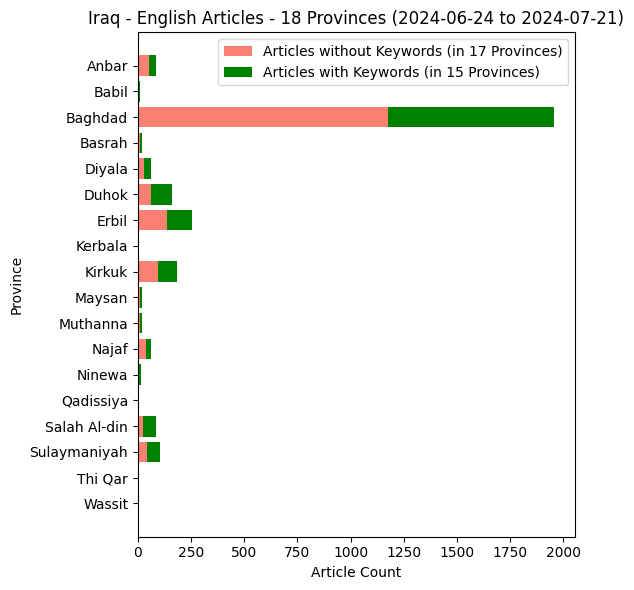

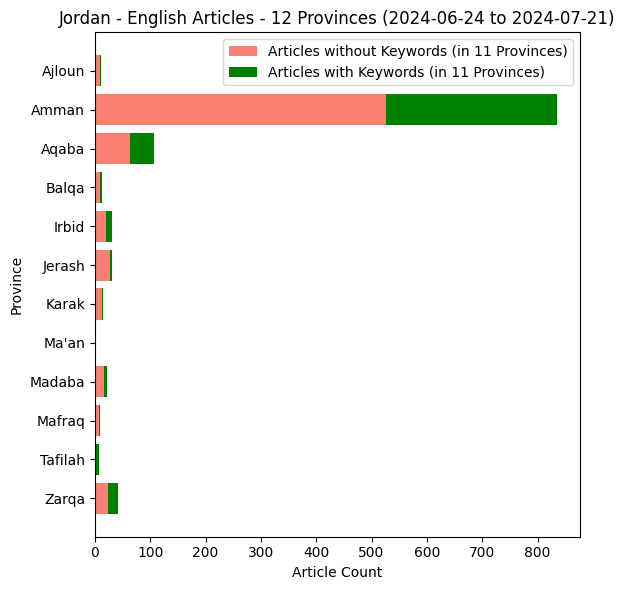

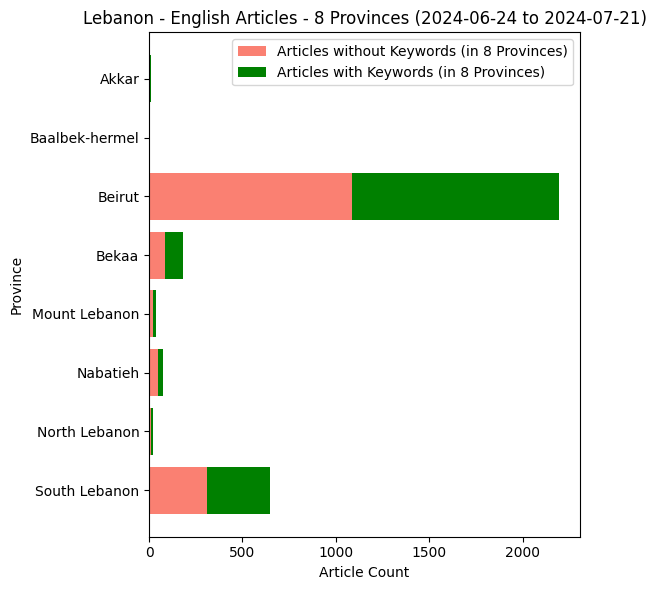

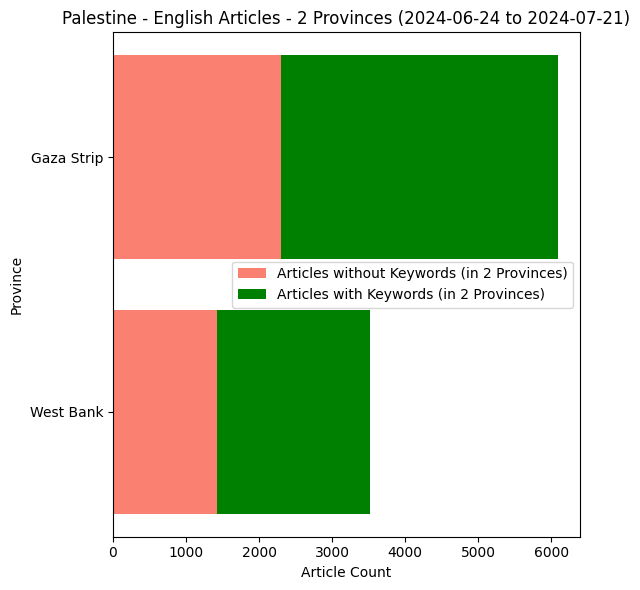

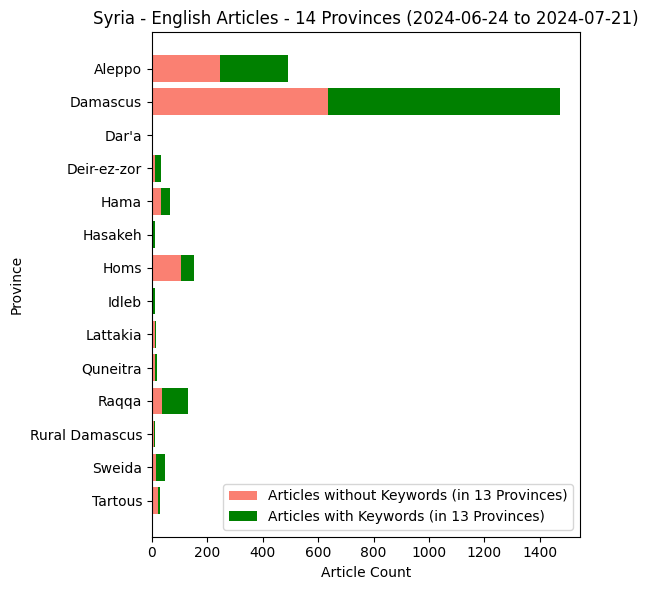

In [149]:
# English
countries = ["Iraq", "Jordan", "Lebanon", "Palestine", "Syria"]
#admin_level = "district"
admin_level = "province"
for country in countries:
    summary_df = summary_df_eng_Y.loc[summary_df_eng_Y["include_country"] == False]
    plot_keyword_province(summary_df = summary_df, language_df = eng, country = country, plot_path = plot_path, admin_level = admin_level, save_plot = True)

### 2.4.4 Plot the article keyword group counts per country

In [150]:
def create_keyword_groups_count(summary_df: pd.DataFrame, language: Literal["eng", "ara"], location: str):
    
    # Filter the dataframe for the specified location
    province_df = summary_df.loc[summary_df["admin_level"] == location]

    # Convert dates to calendar weeks
    province_df["date"] = province_df["date"].dt.isocalendar().week

    # Set the date as the index
    province_df.set_index('date', inplace=True)

    # Select the columns to stack
    columns_to_stack = ['cv', 'pi', 'ha', 'eci', 'prs', 'wc', 'fc', 'lri', 'pad', 'fd', 'ei', 'o']

    # Extract the data for the plot and normalize it
    data_to_plot = province_df[columns_to_stack]
    normalized_data = data_to_plot.div(data_to_plot.sum(axis=1), axis=0)

    # Create a figure with two subplots, one below the other without sharing the x-axis
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5))

    # Plot the absolute counts on the first subplot
    data_to_plot.plot(kind='barh', stacked=True, ax=ax1, colormap='tab20', width=0.85)
    ax1.set_title(f'Absolute Counts of Keyword Containing Articles per Group in {languages[language]} Articles Mentioning {location}')
    ax1.set_ylabel('Calendar Week (2024)')
    ax1.invert_yaxis()  # Invert y-axis to have the latest date at the top
    ax1.legend().remove()  # Remove the legend from the first plot

    # Plot the normalized data on the second subplot
    normalized_data.plot(kind='barh', stacked=True, ax=ax2, colormap='tab20', width=0.85)
    ax2.set_title(f'Share of Keyword Containing Articles per Group in {languages[language]} Articles Mentioning {location}')
    ax2.set_xlabel('Proportion')
    ax2.set_ylabel('Calendar Week (2024)')
    ax2.invert_yaxis()  # Invert y-axis to have the latest date at the top

    # Custom legend labels
    custom_labels = [keyword_codes[col] for col in columns_to_stack]

    # Update legend with custom labels and position it below the second plot
    ax2.legend(custom_labels, title='Keyword Groups', bbox_to_anchor=(0.5, -0.35), loc='upper center', ncol=4)

    # Adjust layout to prevent clipping of the legend and titles
    plt.tight_layout()

    plt.savefig(plot_path + "keyword-province/" + f"weekly_{location}_{language}.png", bbox_inches='tight')
    plt.show()

/tmp/ipykernel_23320/4027880765.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  province_df["date"] = province_df["date"].dt.isocalendar().week


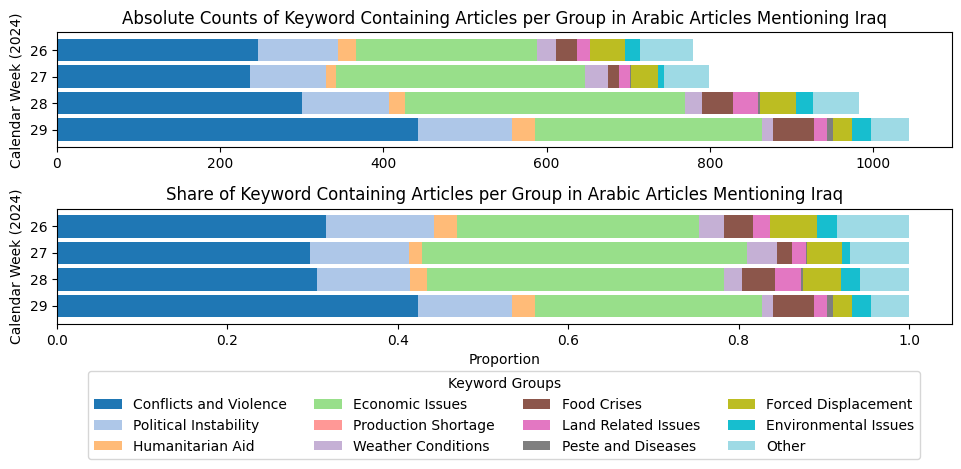

/tmp/ipykernel_23320/4027880765.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  province_df["date"] = province_df["date"].dt.isocalendar().week


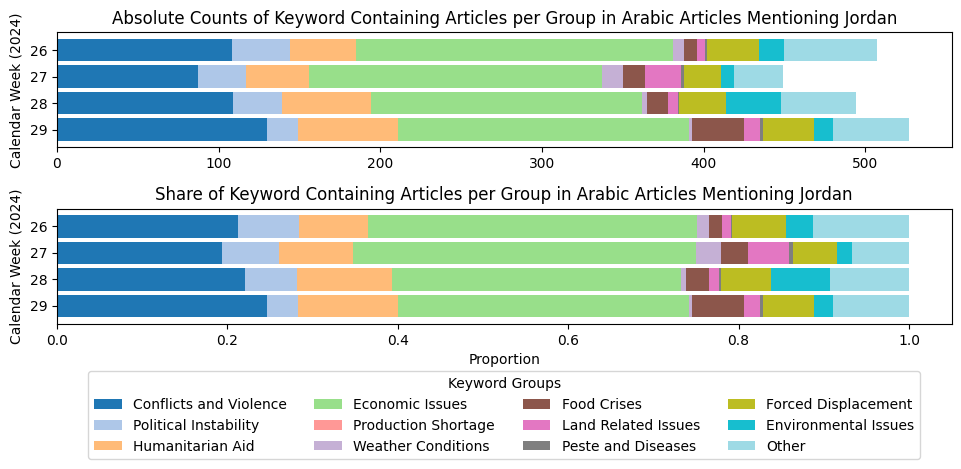

/tmp/ipykernel_23320/4027880765.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  province_df["date"] = province_df["date"].dt.isocalendar().week


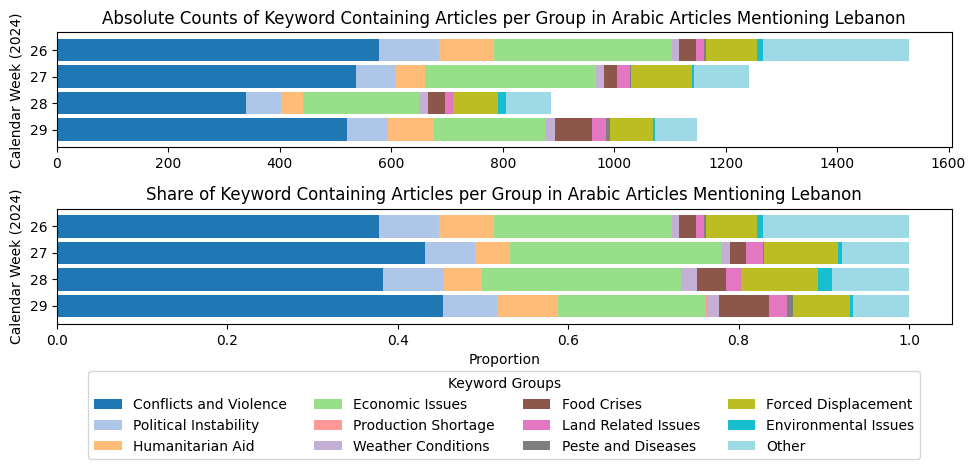

/tmp/ipykernel_23320/4027880765.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  province_df["date"] = province_df["date"].dt.isocalendar().week


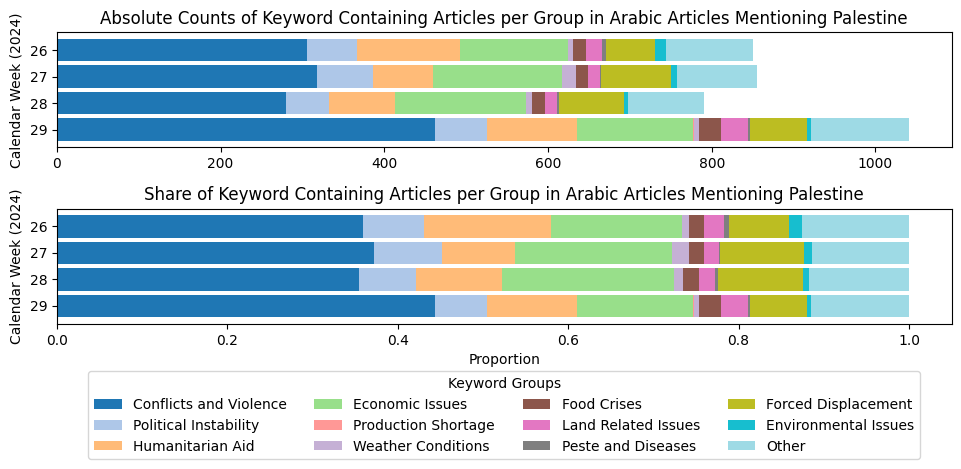

/tmp/ipykernel_23320/4027880765.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  province_df["date"] = province_df["date"].dt.isocalendar().week


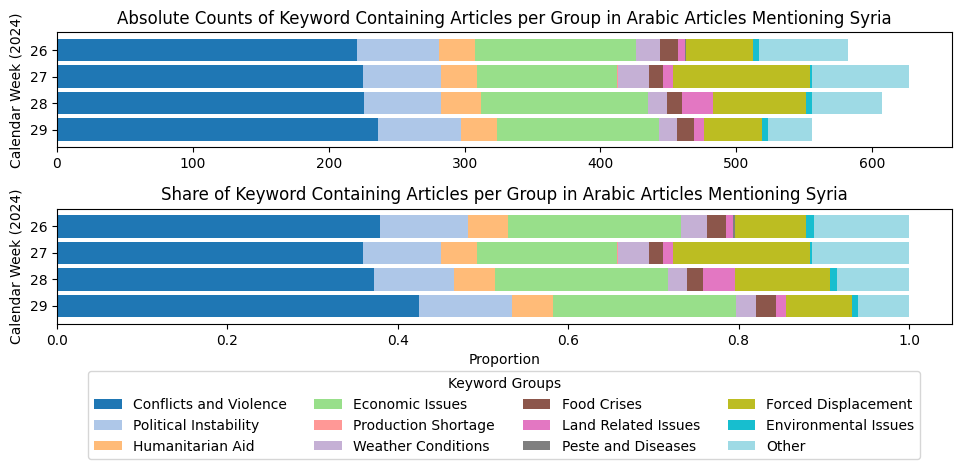

In [151]:
countries = ["Iraq", "Jordan", "Lebanon", "Palestine", "Syria"]

for country in countries:
    summary_df = summary_df_ara_W.loc[summary_df_ara_W["include_country"] == False]
    create_keyword_groups_count(summary_df = summary_df, language = "ara", location = country)

/tmp/ipykernel_23320/4027880765.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  province_df["date"] = province_df["date"].dt.isocalendar().week


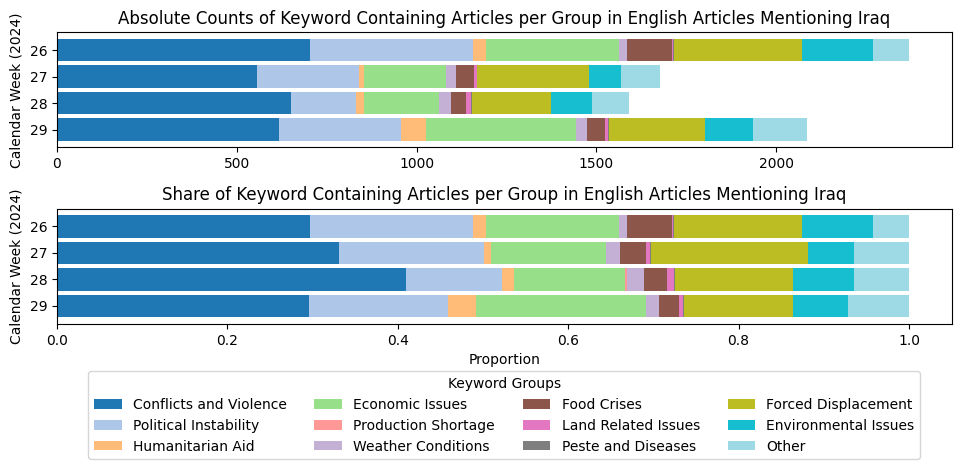

/tmp/ipykernel_23320/4027880765.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  province_df["date"] = province_df["date"].dt.isocalendar().week


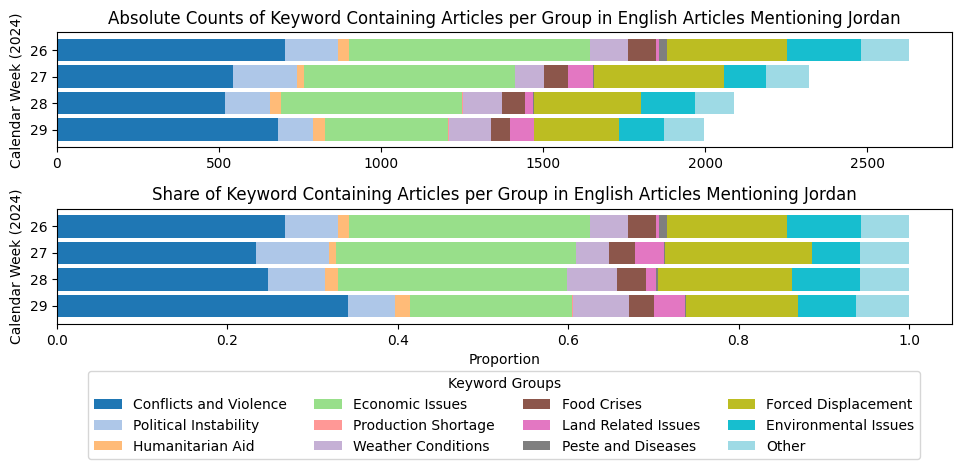

/tmp/ipykernel_23320/4027880765.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  province_df["date"] = province_df["date"].dt.isocalendar().week


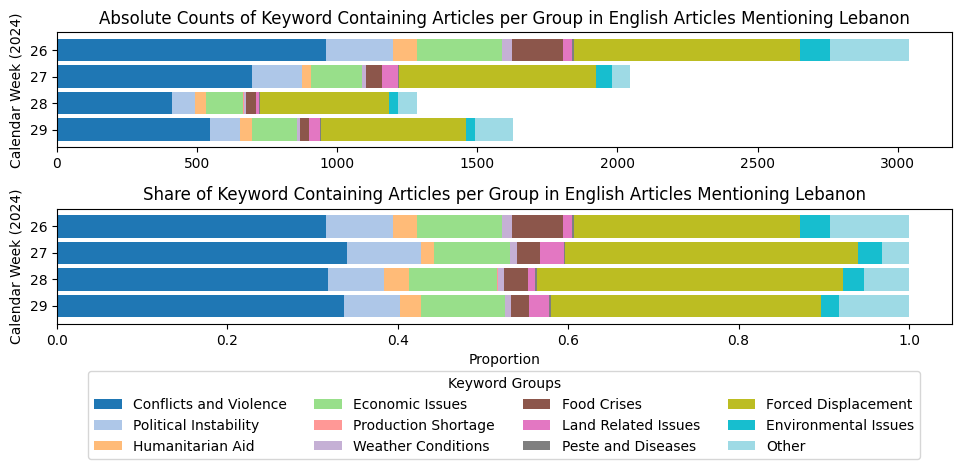

/tmp/ipykernel_23320/4027880765.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  province_df["date"] = province_df["date"].dt.isocalendar().week


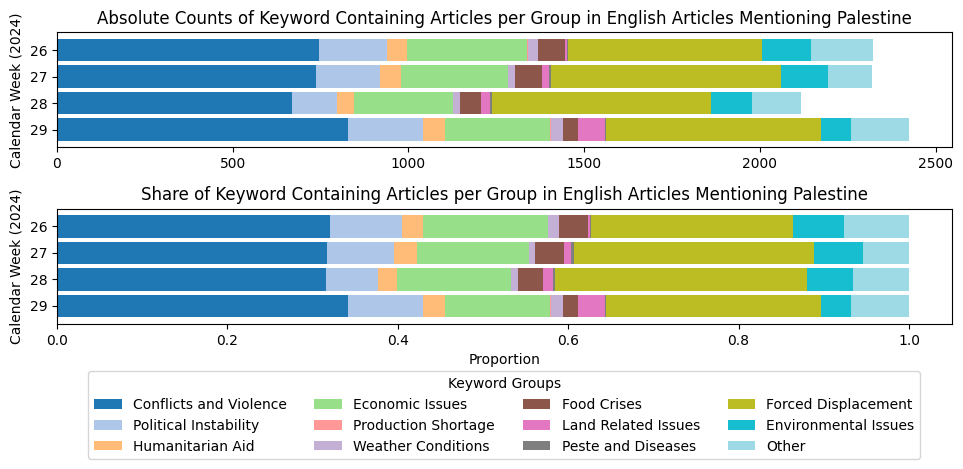

/tmp/ipykernel_23320/4027880765.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  province_df["date"] = province_df["date"].dt.isocalendar().week


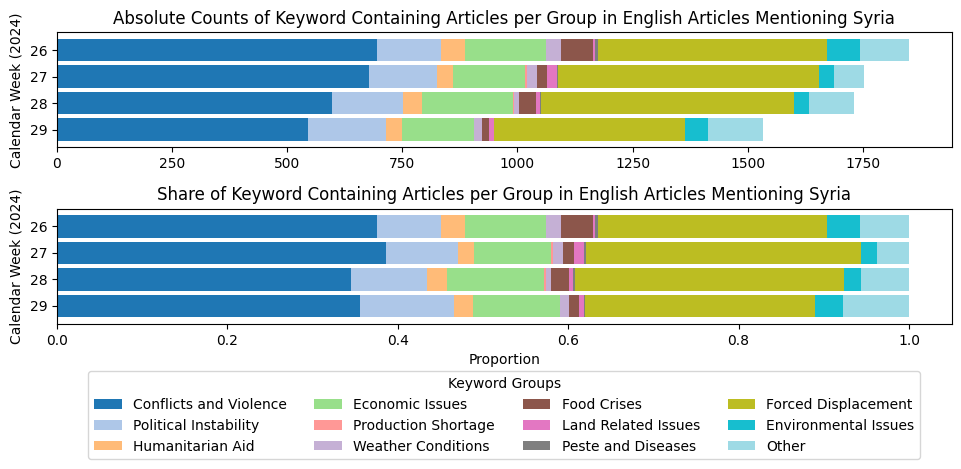

In [194]:
countries = ["Iraq", "Jordan", "Lebanon", "Palestine", "Syria"]

for country in countries:
    summary_df = summary_df_eng_W.loc[summary_df_eng_W["include_country"] == False]
    create_keyword_groups_count(summary_df = summary_df, language = "eng", location = country)

## 2.5 Plotting time series for different locations and keywords

In [153]:
cv_column_names = get_column_names(eng, "cv_")

- iraq: iq
- jordan: jo
- lebanon: lb
- palestine: ps
- syria: sy

In [154]:
eng["cw"] = eng["date"].dt.isocalendar().week

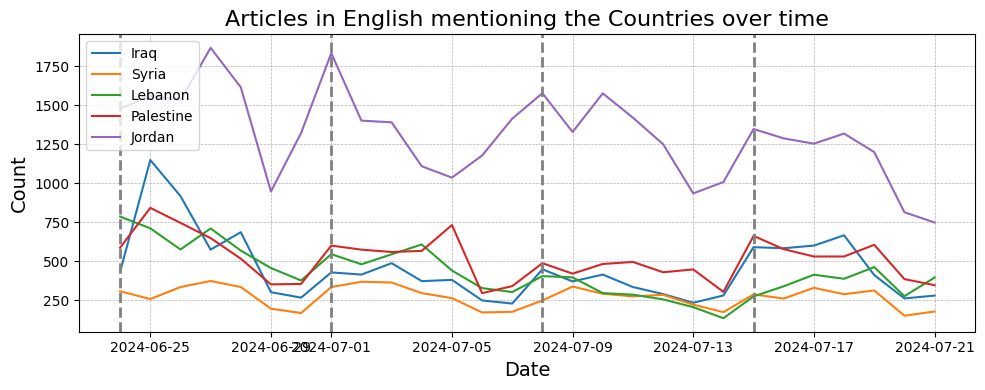

In [155]:
# Plot the data
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(eng.loc[(eng["iq_iraq"] > 0)].groupby("date").size(), label="Iraq")
ax.plot(eng.loc[(eng["sy_syria"] > 0)].groupby("date").size(), label="Syria")
ax.plot(eng.loc[(eng["lb_lebanon"] > 0)].groupby("date").size(), label="Lebanon")
ax.plot(eng.loc[(eng["ps_palestine"] > 0)].groupby("date").size(), label="Palestine")
ax.plot(eng.loc[(eng["jo_jordan"] > 0)].groupby("date").size(), label="Jordan")

# Enhance plot appearance
ax.set_title('Articles in English mentioning the Countries over time', fontsize=16)
ax.set_xlabel('Date', fontsize=14)
ax.set_ylabel('Count', fontsize=14)
ax.legend(loc='upper left')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks()

# Add vertical lines at the end of each calendar week
weeks = eng.groupby("cw")["date"].min().values
for week_end in weeks:
    ax.axvline(x=week_end, color='gray', linestyle='--', linewidth=2)

# Show plot
plt.tight_layout()
plt.show()

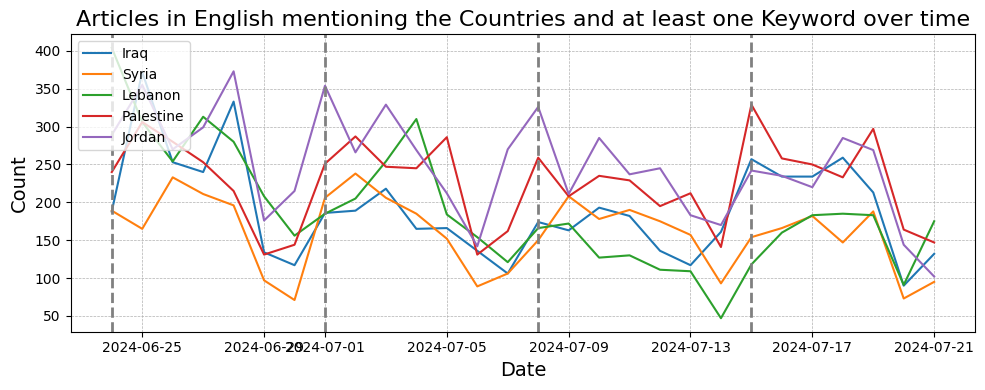

In [156]:
# Plot the data
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(eng.loc[(eng["iq_iraq"] > 0) & (eng["kw_all"] > 0)].groupby("date").size(), label="Iraq")
ax.plot(eng.loc[(eng["sy_syria"] > 0) & (eng["kw_all"] > 0)].groupby("date").size(), label="Syria")
ax.plot(eng.loc[(eng["lb_lebanon"] > 0) & (eng["kw_all"] > 0)].groupby("date").size(), label="Lebanon")
ax.plot(eng.loc[(eng["ps_palestine"] > 0) & (eng["kw_all"] > 0)].groupby("date").size(), label="Palestine")
ax.plot(eng.loc[(eng["jo_jordan"] > 0) & (eng["kw_all"] > 0)].groupby("date").size(), label="Jordan")

# Enhance plot appearance
ax.set_title('Articles in English mentioning the Countries and at least one Keyword over time', fontsize=16)
ax.set_xlabel('Date', fontsize=14)
ax.set_ylabel('Count', fontsize=14)
ax.legend(loc='upper left')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks()

# Add vertical lines at the end of each calendar week
weeks = eng.groupby("cw")["date"].min().values
for week_end in weeks:
    ax.axvline(x=week_end, color='gray', linestyle='--', linewidth=2)

# Show plot
plt.tight_layout()
plt.show()

In [192]:
iraq_df = summary_df_eng.loc[(summary_df_eng["country"] == "Iraq") & (summary_df_eng["admin_level"] == "Iraq")]
iraq_df.reset_index(inplace=True)

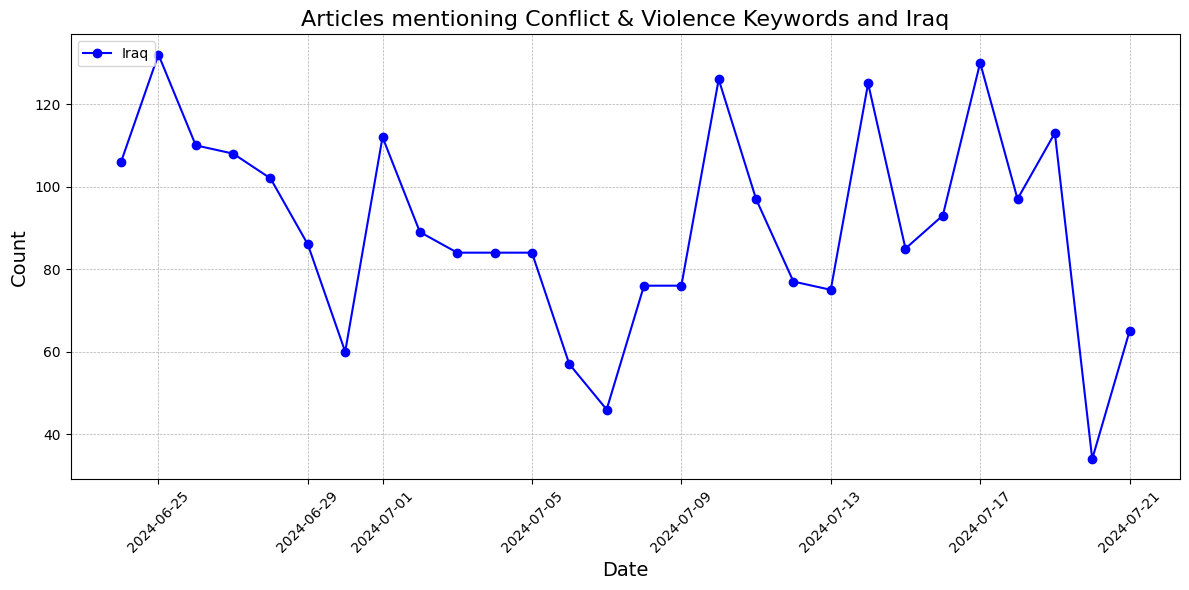

In [193]:
# Plot the data
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(iraq_df["date"], iraq_df["cv"], label="Iraq", color='blue', marker='o', linestyle='-')

# Enhance plot appearance
ax.set_title('Articles mentioning Conflict & Violence Keywords and Iraq', fontsize=16)
ax.set_xlabel('Date', fontsize=14)
ax.set_ylabel('Count', fontsize=14)
ax.legend(loc='upper left')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(rotation=45)

# Show plot
plt.tight_layout()
plt.show()

## 2.6 Time Series

In [153]:
country_codes = {"iq": "Iraq", "jo": "Jordan", "lb": "Lebanon", "ps": "Palestine", "sy": "Syria"}
admin_level_code = {"pr": "Province", "di": "District"}
keyword_codes = {"cv": "Conflicts and Violence", "pi": "Political Instability", "ha": "Humanitarian Aid", "eci": "Economic Issues", "prs": "Production Shortage", "wc": "Weather Conditions", "fc": "Food Crises", "lri": "Land Related Issues", "pad": "Peste and Diseases", "fd": "Forced Displacement", "ei": "Environmental Issues", "o": "Other", "kw" : "All Keywords"}       
languages = {"ara": "Arabic", "eng": "English"}

In [282]:
summary_df_eng = pd.read_csv(eng_data_folder + "Mashreq_2024-06-23_2024-07-24_daily_article_eng_clean_summary.csv")

In [283]:
location = list(country_codes.values())[0]
summary_df_loc = summary_df_eng.loc[summary_df_eng["admin_level"] == location]
keyword_groups = list(keyword_codes.keys())[:-1]

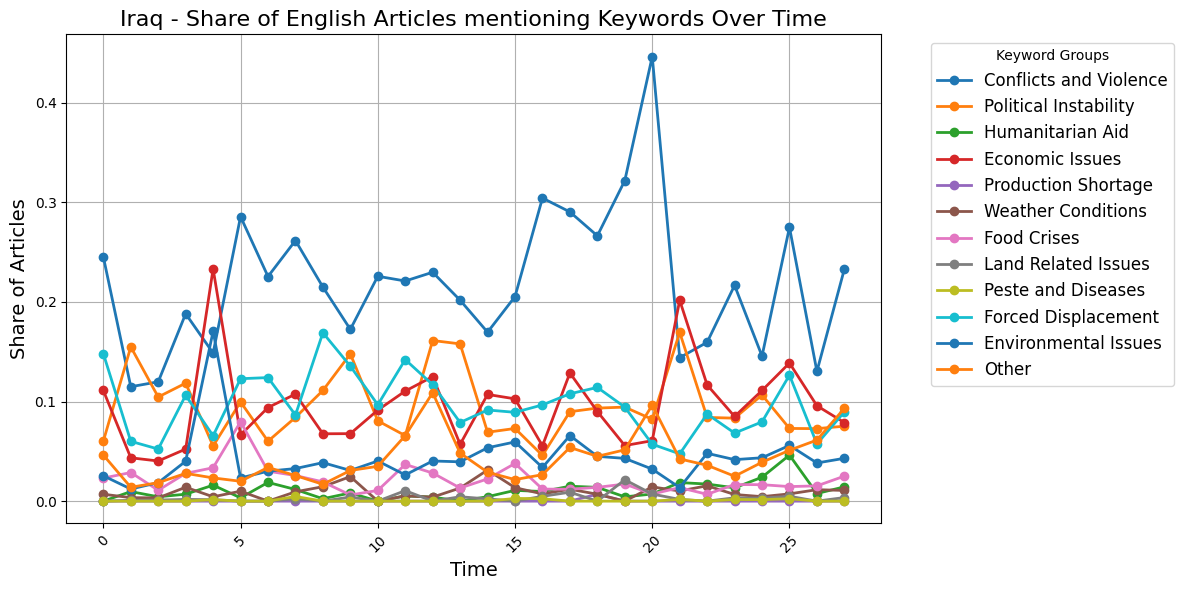

In [284]:
# Plotting
plt.figure(figsize=(12, 6))

# Normalize data and plot
normalized_data = summary_df_loc[keyword_groups].apply(lambda x: x / summary_df_loc["count_articles"])
for keyword in keyword_groups:
    plt.plot(normalized_data[keyword], marker='o', linestyle='-', linewidth=2, label=keyword)

# Adding title and labels
plt.title(f'{location} - Share of English Articles mentioning Keywords Over Time', fontsize=16)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Share of Articles', fontsize=14)

# Adding a legend
plt.legend(list(keyword_codes.values()), title='Keyword Groups', loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=12)

# Improve date formatting if the x-axis represents dates
plt.xticks(rotation=45)

# Adding grid lines for better readability
plt.grid(True)

# Adjust layout to accommodate the legend outside the plot
plt.tight_layout()

# Show the plot
plt.show()

In [296]:
category_keywords_list = [get_column_names(eng, keyword + "_") for keyword in list(keyword_codes.keys())]
category_keywords = category_keywords_list[0]
keyword_group_name = list(keyword_codes.values())[0]
category_keyword_names = [" ".join([word.capitalize() for word in category_keyword.split("_")[1:]]) for category_keyword in category_keywords]

/tmp/ipykernel_68748/4235142565.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', 10)  # Adjusting colormap for 10 colors


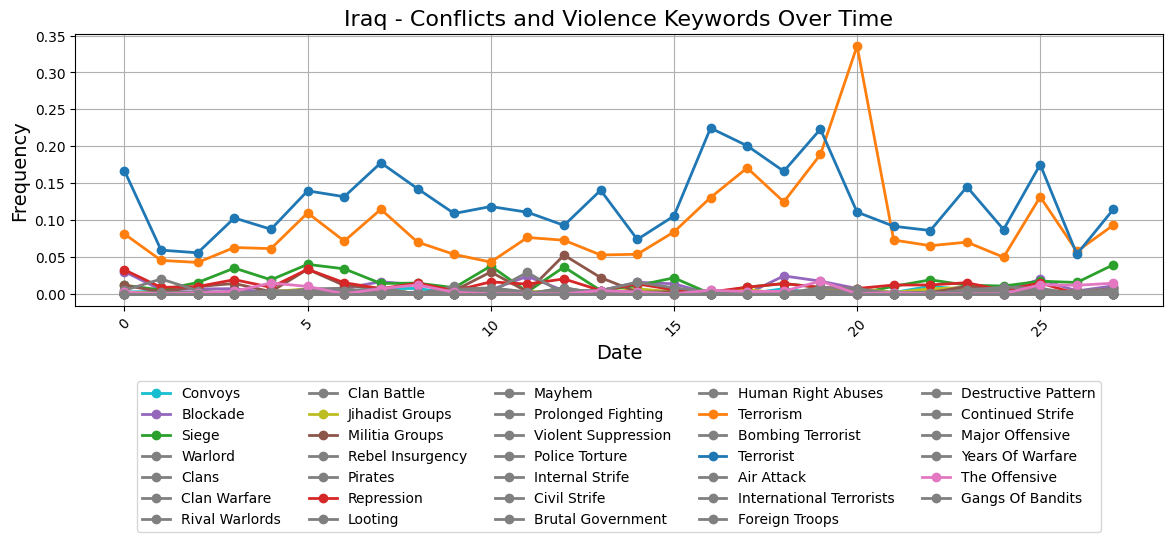

In [298]:
# Plotting
plt.figure(figsize=(12, 6))

# Normalize data and plot
normalized_data = summary_df_loc[category_keywords].apply(lambda x: x / summary_df_loc["count_articles"])

location_name = [word.capitalize() for word in location.split("_") [1:]][0]

# Calculate the average frequency for each keyword
average_frequencies = normalized_data[category_keywords].mean()

# Create a colormap for the top 10
colors = plt.cm.get_cmap('tab10', 10)  # Adjusting colormap for 10 colors

# Sort keywords by their average frequency and get the top 10
top_10_keywords = average_frequencies.nlargest(10).index.tolist()

# Adding title and labels
plt.title(f'{location_name} - Share of English Articles mentioning Keywords Over Time', fontsize=16)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Share of Articles', fontsize=14)

# Loop through each category and plot
for i, keyword in enumerate(category_keywords):
    if keyword in top_10_keywords:
        # Use a different color for the top 10 keywords
        color = colors(top_10_keywords.index(keyword))
    else:
        # Use grey color for the other keywords
        color = 'grey'
    plt.plot(normalized_data[keyword], marker='o', linestyle='-', linewidth=2, color=color)

# Adding title and labels
plt.title(f'{location_name} - {keyword_group_name} Keywords Over Time', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# Adding a legend only for the top 10 keywords
top_10_keyword_names = [category_keyword_names[category_keywords.index(k)] for k in top_10_keywords]
plt.legend(category_keyword_names, loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=5)

# Improve date formatting if the x-axis represents dates
plt.xticks(rotation=45)

# Adding grid lines for better readability
plt.grid(True)

# Adjust layout to accommodate the legend outside the plot
plt.tight_layout()

# Show the plot
plt.show()

In [285]:
category_keywords_list = [get_column_names(eng, keyword + "_") for keyword in list(keyword_codes.keys())]
category_keywords_all = np.concatenate(category_keywords_list)

In [286]:
location = get_column_names(eng, "iq_")[0]
location

'iq_iraq'

In [159]:
relevant_columns = np.concat([[location], category_keywords_all])

df = eng.loc[eng[location] > 0].copy().reset_index(drop=True)

for relevant_column in relevant_columns:
    df.loc[df[relevant_column] > 0, relevant_column] = 1
    
df_per_day = df.groupby("date").sum()[relevant_columns]

df_per_day[category_keywords_all] = df_per_day[category_keywords_all].apply(lambda x: x / df_per_day[location])

/tmp/ipykernel_68748/2165052030.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', 10)  # Adjusting colormap for 10 colors


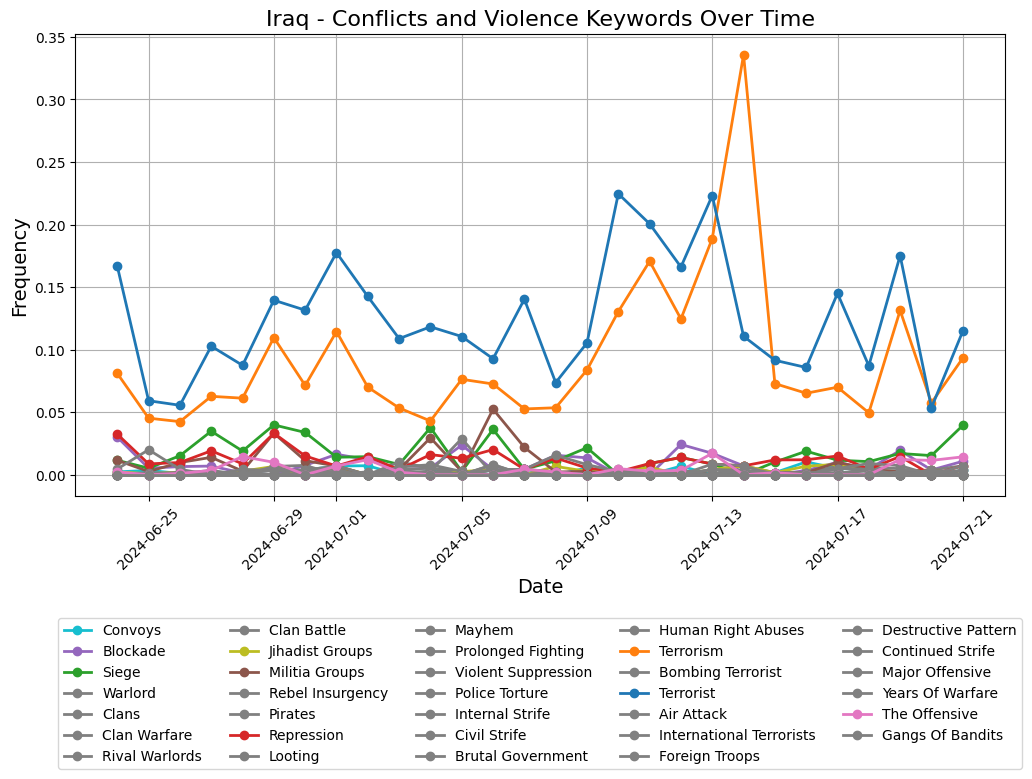

In [160]:
# Assuming category_keywords is defined
id = 0
keyword_group_name = list(keyword_codes.values())[id]
category_keywords = category_keywords_list[id]
category_keyword_names = [" ".join([word.capitalize() for word in category_keyword.split("_")[1:]]) for category_keyword in category_keywords]

location_name = [word.capitalize() for word in location.split("_") [1:]][0]

# Calculate the average frequency for each keyword
average_frequencies = df_per_day[category_keywords].mean()

# Sort keywords by their average frequency and get the top 10
top_10_keywords = average_frequencies.nlargest(10).index.tolist()

# Create a colormap for the top 10
colors = plt.cm.get_cmap('tab10', 10)  # Adjusting colormap for 10 colors

# Plotting
plt.figure(figsize=(12, 6))

# Loop through each category and plot
for i, keyword in enumerate(category_keywords):
    if keyword in top_10_keywords:
        # Use a different color for the top 10 keywords
        color = colors(top_10_keywords.index(keyword))
    else:
        # Use grey color for the other keywords
        color = 'grey'
    plt.plot(df_per_day[keyword], marker='o', linestyle='-', linewidth=2, color=color)

# Adding title and labels
plt.title(f'{location_name} - {keyword_group_name} Keywords Over Time', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# Adding a legend only for the top 10 keywords
top_10_keyword_names = [category_keyword_names[category_keywords.index(k)] for k in top_10_keywords]
plt.legend(category_keyword_names, loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=5)

# Improve date formatting if the x-axis represents dates
plt.xticks(rotation=45)

# Adding grid lines for better readability
plt.grid(True)

# Show the plot
plt.show()

# 3. Check for paywalls

In [196]:
# This will delete all variables from the current session
%reset -f

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from typing import Literal
from datetime import datetime, timedelta

In [197]:
ara_data_folder = "../../data/newsapi/downloads/ara/"
eng_data_folder = "../../data/newsapi/downloads/eng/"

plot_path = "../../plots/"

In [198]:
# English
eng = pd.read_csv(eng_data_folder + "Mashreq_2024-06-23_2024-07-24_daily_article_eng_clean.csv")
eng["date"] = pd.to_datetime(eng["date"])

/tmp/ipykernel_23320/2811966821.py:2: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  eng = pd.read_csv(eng_data_folder + "Mashreq_2024-06-23_2024-07-24_daily_article_eng_clean.csv")


In [199]:
# Arabic
ara = pd.read_csv(eng_data_folder + "Mashreq_2024-06-23_2024-07-24_daily_article_ara_clean.csv")
ara["date"] = pd.to_datetime(ara["date"])

In [200]:
# Exclude the dates from the language dataframes to make sure that we only include entire weeks
from_date = "2024-06-24"
to_date = "2024-07-21"

In [201]:
# English
eng = eng.loc[(eng["date"] >= from_date) & (eng["date"] <= to_date),]

In [202]:
# Arabic
ara = ara.loc[(ara["date"] >= from_date) & (ara["date"] <= to_date),]

In [283]:
# Function to count keyword occurrences in an article
def count_keywords(article, paywall_keywords):
    return sum(article.lower().count(keyword) for keyword in paywall_keywords)

## 3.1 English articles

In [284]:
# Defining a list of words likely to appear in paywalls
paywall_keywords_eng = [
    "subscribe",
    "subscription",
    "sign up",
    "subscribe now",
    "register",
    "register now",
    "become a subscriber",
    "exclusive content",
    "member",
    "membership",
    "paywall",
    "pay",
    "payment",
    "purchase",
    "paid content",
    "buy now",
    "access to",
    "read more",
    "continue reading",
    "read the full article",
    "log in to read more",
    "unlock",
    "access"
    "get access",
    "full access",
    "free trial",
    "start your free trial",
    "trial period",
    "login",
    "log in",
    "already a subscriber?",
    "only available to subscribers",
    "upgrade",
    "upgrade your plan",
    "sign in",
    "sign in to continue",
    "premium",
    "join now",
    "create an account",
    "limited access",
    "exclusive access",
    "premium content",
    "exclusive articles",
    "limited content",
    "subscription required",
    "password"
]

In [285]:
# Apply the function to the DataFrame
eng['paywall_keyword_count'] = eng['body'].apply(count_keywords, args=(paywall_keywords_eng,))
eng["article_length"] = eng['body'].apply(lambda x: len(x.split(" ")))
eng["paywall_probability"] = eng["paywall_keyword_count"] / eng["article_length"]

In [286]:
paywall_200 = eng.sort_values("paywall_probability", ascending = False).head(200)[["paywall_probability", "url", "source", "body"]]

In [287]:
paywall_200.to_csv(eng_data_folder + "paywall_200.csv", index = False)

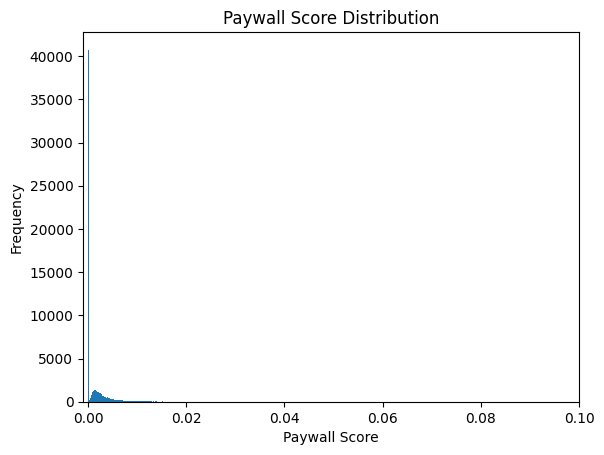

In [288]:
plt.hist(eng['paywall_probability'], bins=1000)
plt.title('Paywall Score Distribution')
plt.xlabel('Paywall Score')
plt.ylabel('Frequency')
plt.xlim(-0.001, 0.1)
plt.show()

In [289]:
sum(eng["paywall_keyword_count"] == 0)

40740

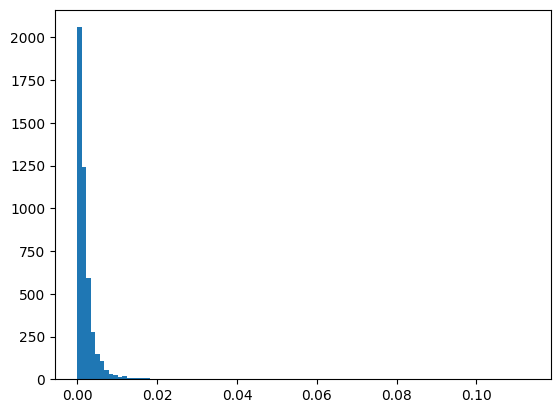

In [290]:
plt.hist(eng.groupby("source")["paywall_probability"].mean(), bins=100)
plt.show()

## 3.2 Arabic articles

In [291]:
paywall_keywords_ara = [
    "اشترك", "اشترك الآن", "لمتابعة", "للاطلاع", "مقال مدفوع",
    "محتوى خاص", "تسجيل الدخول", "إصدار بريميوم", "إشتراك",
    "إلغاء الاشتراك", "اشتركت", "تفعيل الاشتراك", "استمر في القراءة",
    "عرض كامل", "محتوى حصري", "حسابك", "ترقية", "التسجيل",
    "تسجيل الدخول لمتابعة القراءة", "اشترِ الآن", "المقال الكامل",
    "الدفع", "اشتر الآن", "الوصول الكامل", "القراءة الكاملة",
    "مقال كامل", "إشترك لتستفيد", "إشتراكك", "محتوى مدفوع",
    "عرض المزيد", "المزيد من التفاصيل", "إدارة الحساب",
    "قم بتسجيل الدخول", "تسجيل الدخول لقراءة المزيد", "ادفع الآن",
    "مقالة مدفوعة", "اشترك لمتابعة", "الاشتراك", "العضوية",
    "تابع القراءة", "حصري لأعضاء", "الترقية", "الوصول إلى المحتوى"
]

In [296]:
paywall_keywords_ara2 = [
    "اشترك", "اشتراك", "سجل", "اشترك الآن", "تسجيل", "سجل الآن",
    "كن مشتركًا", "محتوى حصري", "عضو", "عضوية", "حاجز دفع",
    "ادفع", "دفع", "شراء", "محتوى مدفوع", "اشترِ الآن", "الوصول إلى",
    "اقرأ المزيد", "استمر في القراءة", "اقرأ المقال كاملاً",
    "سجل الدخول لقراءة المزيد", "افتح", "وصول", "احصل على وصول",
    "وصول كامل", "تجربة مجانية", "ابدأ تجربتك المجانية",
    "فترة تجريبية", "تسجيل الدخول", "تسجيل الدخول",
    "هل أنت مشترك بالفعل؟", "متاح فقط للمشتركين", "ترقية",
    "قم بترقية خطتك", "تسجيل الدخول", "تسجيل الدخول للمتابعة",
    "بريميوم", "انضم الآن", "أنشئ حسابًا", "وصول محدود",
    "وصول حصري", "محتوى بريميوم", "مقالات حصرية", "محتوى محدود",
    "يتطلب الاشتراك", "كلمة المرور"
]


In [297]:
# Apply the function to the DataFrame
ara['paywall_keyword_count'] = ara['body'].apply(count_keywords, args=(paywall_keywords_ara2,))
ara["article_length"] = ara['body'].apply(lambda x: len(x.split(" ")))
ara["paywall_probability"] = ara["paywall_keyword_count"] / ara["article_length"]

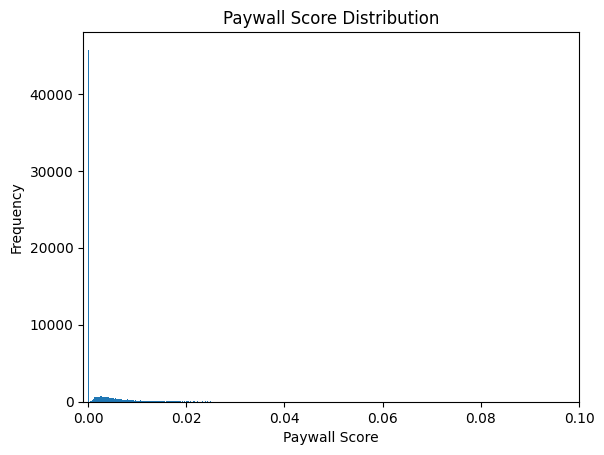

In [299]:
plt.hist(ara['paywall_probability'], bins=1000)
plt.title('Paywall Score Distribution')
plt.xlabel('Paywall Score')
plt.ylabel('Frequency')
plt.xlim(-0.001, 0.1)
plt.show()